# Exploration 4: 임베딩 내 편향성 알아보기

In [12]:
import konlpy
import gensim
import sklearn
import seaborn

print(konlpy.__version__)
print(gensim.__version__)
print(sklearn.__version__)
print(seaborn.__version__)

0.6.0
4.4.0
1.7.0
0.13.2


In [13]:
genre_txt = ['synopsis_SF.txt', 'synopsis_family.txt', 'synopsis_show.txt', 'synopsis_horror.txt', 'synopsis_etc.txt',
             'synopsis_documentary.txt', 'synopsis_drama.txt', 'synopsis_romance.txt', 'synopsis_musical.txt',
             'synopsis_mystery.txt', 'synopsis_crime.txt', 'synopsis_historical.txt', 'synopsis_western.txt',
             'synopsis_adult.txt', 'synopsis_thriller.txt', 'synopsis_animation.txt', 'synopsis_action.txt',
             'synopsis_adventure.txt', 'synopsis_war.txt', 'synopsis_comedy.txt', 'synopsis_fantasy.txt']
genre_name = ['SF', '가족', '공연', '공포(호러)', '기타', '다큐멘터리', '드라마', '멜로로맨스', '뮤지컬', '미스터리', '범죄', '사극', '서부극(웨스턴)',
         '성인물(에로)', '스릴러', '애니메이션', '액션', '어드벤처', '전쟁', '코미디', '판타지']

## STEP 1. 형태소 분석기를 이용하여 품사가 명사인 경우 해당 단어 추출하기 

### 1. 장르별 명사 추출 및 코퍼스 생성

In [14]:
import os

data_dir = os.path.join(os.getenv("HOME"), "work/AIFFEL_quest_rs/Exploration/Ex04/data")
file_name = os.path.join(data_dir, "synopsis.txt")

# 파일이 정말 있는지 먼저 체크
if os.path.exists(file_name):
    print("파일을 찾았습니다! 내용을 출력합니다.\n")
    with open(file_name, 'r', encoding='utf-8') as file: # encoding 추가 권장
        for i in range(5):
            print(file.readline(), end='')
else:
    print(f"에러: {file_name} 경로에 파일이 없습니다. 경로를 다시 확인해주세요!")

파일을 찾았습니다! 내용을 출력합니다.

사운드 엔지니어 상우(유지태 분)는 치매에 걸린 할머니(백성희 분)와
 젊은 시절 상처한 한 아버지(박인환 분), 고모(신신애 분)와 함께 살고 있다.
 어느 겨울 그는 지방 방송국 라디오 PD 은수(이영애 분)를 만난다.
 자연의 소리를 채집해 틀어주는 라디오 프로그램을 준비하는 은수는 상우와 녹음 여행을 떠난다.
 자연스레 가까워지는 두 사람은 어느 날, 은수의 아파트에서 밤을 보낸다.


In [15]:
from konlpy.tag import Okt
from tqdm import tqdm  # 진행 상황을 보기 위해 추가

okt = Okt()

# 1. Word2Vec 학습용: 모든 문장의 명사 리스트를 담을 곳 (이중 리스트)
tokenized = [] 

# 2. TF-IDF용: 장르별로 모든 명사를 합친 문자열을 담을 곳 (단일 리스트)
genre_res = []

for file_name in tqdm(genre_txt):  # 21개 파일을 하나씩 꺼냅니다.
    sentence_list = []  # 이번 장르 파일의 모든 명사를 합칠 변수
    
    with open(os.path.join(data_dir, file_name), 'r', encoding='utf-8') as file:
        while True:
            line = file.readline()
            if not line: break
            
            # 형태소 분석
            words = okt.pos(line, stem=True, norm=True)
            
            res = []
            for w in words:
                if w[1] in ["Noun"]: # 명사만 추출
                    res.append(w[0])
                    sentence_list.append(w[0]) # 장르별 뭉치에 추가
            
            # Word2Vec용: 한 문장에 명사가 하나라도 있으면 추가
            if len(res) > 0:
                tokenized.append(res)
                
    # TF-IDF용: 이 장르에서 나온 모든 명사를 공백으로 합쳐서 저장
    genre_res.append(" ".join(sentence_list))

print(f"\n총 {len(tokenized)}개의 문장 토큰화 완료!")
print(f"총 {len(genre_res)}개의 장르 텍스트 생성 완료!")

100%|██████████| 21/21 [08:55<00:00, 25.51s/it]


총 68427개의 문장 토큰화 완료!
총 21개의 장르 텍스트 생성 완료!


### 2. 추출 결과 확인하기

In [16]:
# 1. 전체 문장 개수 및 샘플 확인 (Word2Vec용)
print("=== Word2Vec용 tokenized 샘플 (첫 5개 문장) ===")
print(f"전체 문장 수: {len(tokenized)}")
for i, tokens in enumerate(tokenized[:5]):
    print(f"문장 {i+1}: {tokens}")

print("\n" + "="*50 + "\n")

# 2. 장르별 데이터 개수 및 샘플 확인 (TF-IDF용)
print("=== TF-IDF용 genre_res 샘플 (첫 장르: " + genre_name[0] + ") ===")
print(f"전체 장르 수: {len(genre_res)}")

# 첫 번째 장르의 명사 뭉치 중 앞부분 200자만 출력
print(f"'{genre_name[0]}' 장르 앞부분: {genre_res[0][:200]}...")

=== Word2Vec용 tokenized 샘플 (첫 5개 문장) ===
전체 문장 수: 68427
문장 1: ['시간', '지명', '알', '수', '한국', '가상', '도시', '산성비', '오염', '이', '도시', '기억', '망각', '바이러스', '존재', '소문', '시작', '기억', '위해', '사람', '곳', '어', '두운', '기억', '안나', '역시', '망각', '바이러스', '그녀', '사람', '바이러스', '가이드', '유키', '고아', '출신', '여행사', '소속', '택시', '운전사', '나비', '떼', '바이러스', '지역', '인도', '정보', '산성비', '위험', '무릅쓰', '세', '사람', '도착', '곳', '공사', '현장', '곳', '안나', '나비', '떼', '가이드', '또한', '그', '구슬', '소리', '등', '분위기', '자신', '기억', '환각', '속', '한편', '가이드', '유키', '납중독', '상태', '임', '임신', '개월', '아이', '것', '알', '안나', '그녀', '하나', '인연', '끈', '유키', '유키', '산성비', '노출', '안나', '정성껏', '자신', '캡슐', '하우스', '영상', '기억', '자신', '누군가', '기억', '바랬던', '소녀', '셀프', '비디오', '또한', '망각', '바이', '스', '기억', '사람', '간', '여권', '안나', '기억', '자신', '간직', '안나', '망각', '향', '돌진', '자신', '뒤', '유케', '묘', '우정']
문장 2: ['유키', '평소', '사이', '택시', '운전사', '의', '신고', '납중독', '환자', '격리', '소', '안나', '둘이서', '여행', '계속', '의', '무례', '합승', '안나', '감정', '폭발', '안나', '고아', '자신', '누군가', '기억', '가족', '수', '희망', '때문', '합승'

---

## STEP 2. 추출된 결과로 embedding model 만들기

In [17]:
from gensim.models import Word2Vec

# 1. 모델 학습 시작 (데이터 양에 따라 수 초~수 분 소요)
print("Word2Vec 모델 학습 중...")
model = Word2Vec(tokenized, vector_size=100, window=5, min_count=3, sg=0)
print("학습 완료!")

# 2. 모델 테스트: '영화'과 유사한 단어 찾아보기
test_word = "영화"
if test_word in model.wv:
    print(f"'{test_word}'와 가장 유사한 단어들:")
    print(model.wv.most_similar(test_word))
else:
    print(f"'{test_word}' 단어가 모델에 없습니다.")

Word2Vec 모델 학습 중...
학습 완료!
'영화'와 가장 유사한 단어들:
[('작품', 0.90177321434021), ('다큐멘터리', 0.8809743523597717), ('드라마', 0.834758460521698), ('소설', 0.823409378528595), ('영화로', 0.8128470778465271), ('코미디', 0.7900806665420532), ('주제', 0.779863178730011), ('실화', 0.7785641551017761), ('영상', 0.774941623210907), ('설정', 0.7698977589607239)]


### '영화'와 유사한 단어로 '작품', '드라마', '코미디', '소설' 등이 나왔다. 이는 의미적으로 관련 있는 단어들이므로, 임베딩 모델이 정상적으로 학습되었음을 확인할 수 있다.

---

## STEP 3. target, attribute 단어 셋 만들기

### 1. Target 단어 셋 만들기(예술영화/일반영화)

In [18]:
import os
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from konlpy.tag import Okt

art_txt = 'synopsis_art.txt'
gen_txt = 'synopsis_gen.txt'

def read_token(file_name):
    okt = Okt()
    result = []
    with open(data_dir + '/' + file_name, 'r') as fread:
        print(file_name, '파일을 읽고 있습니다.')
        while True:
            line = fread.readline()
            if not line: break
            tokenlist = okt.pos(line, stem=True, norm=True)
            for word in tokenlist:
                if word[1] in ["Noun"]:#, "Adjective", "Verb"]:
                    result.append((word[0]))
    return ' '.join(result)

art_text = read_token(art_txt)    # 'synopsis_art.txt'를 읽고 명사 추출
gen_text = read_token(gen_txt)

synopsis_art.txt 파일을 읽고 있습니다.
synopsis_gen.txt 파일을 읽고 있습니다.


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. TF-IDF용 데이터 구성 (0번: 예술, 1번: 일반)
target_texts = [art_text, gen_text] 

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(target_texts)
vocab = vectorizer.get_feature_names_out()

# 2. 상위 100개 단어 추출 함수
def get_top_n_words(matrix, index, vocab, n=100):
    row = matrix.getrow(index).toarray()[0]
    top_indices = row.argsort()[-n:][::-1]
    return [vocab[i] for i in top_indices if row[i] > 0]

# 예술(A), 일반(B) 영화의 상위 100개 후보군
art_candidates = get_top_n_words(tfidf_matrix, 0, vocab, n=100)
gen_candidates = get_top_n_words(tfidf_matrix, 1, vocab, n=100)

# 3. 중복 제거 및 최종 단어 선정
# 두 후보군에 공통으로 들어있는 단어(교집합)를 찾아 제거합니다.
intersect = set(art_candidates) & set(gen_candidates)

# 중복되지 않은 단어 중 상위 15개를 최종 Target 셋으로 선정
final_art_set = [w for w in art_candidates if w not in intersect and w in model.wv][:15]
final_gen_set = [w for w in gen_candidates if w not in intersect and w in model.wv][:15]

print("최종 예술영화(A) 단어 셋:", final_art_set)
print("최종 일반영화(B) 단어 셋:", final_gen_set)

최종 예술영화(A) 단어 셋: ['아빠', '음악', '운명', '결심', '지금', '여인', '이름', '이후', '준비', '만난', '감정', '처음', '충격', '누구', '그린']
최종 일반영화(B) 단어 셋: ['서울', '애니메이션', '여성', '가지', '주인공', '대해', '연출', '사회', '다큐멘터리', '부문', '섹스', '바로', '의도', '계획', '정체']


### 2. Attribute 단어 셋 만들기

In [20]:
from collections import Counter

# 1. 장르별 TF-IDF
genre_vectorizer = TfidfVectorizer()
genre_tfidf = genre_vectorizer.fit_transform(genre_res)
genre_vocab = genre_vectorizer.get_feature_names_out()

# 2. 장르별 상위 200개 후보 추출 (넉넉하게)
genre_candidates = {}
for i, name in enumerate(genre_name):
    genre_candidates[name] = get_top_n_words(genre_tfidf, i, genre_vocab, n=200)

# 3. 중복 기준을 자동으로 완화하며 15개 채우기
all_words = [w for words in genre_candidates.values() for w in words]
word_counts = Counter(all_words)

genre_word_sets = {}
for name, candidates in genre_candidates.items():
    # 중복 기준을 2부터 시작해서 15개가 될 때까지 올림
    for threshold in range(2, 22):
        common_words = {w for w, c in word_counts.items() if c >= threshold}
        filtered = [w for w in candidates 
                    if w not in common_words 
                    and w in model.wv][:15]
        if len(filtered) >= 15:
            genre_word_sets[name] = filtered
            break
    else:
        # 그래도 부족하면 가능한 만큼 저장
        genre_word_sets[name] = filtered

# 4. 결과 확인
for name, words in genre_word_sets.items():
    print(f"{name} ({len(words)}개): {words}")

SF (15개): ['외계', '시스템', '스타크', '리플리', '켈빈', '컨트', '수퍼맨', '외계인', '분파', '상어', '진화', '물체', '수트', '히노키', '섹터']
가족 (15개): ['아주르', '낙타', '씨제이', '동구', '슈이트', '마갈', '미아', '펠리칸', '벤트', '케이시', '최호', '혜지', '유나', '테리', '손녀']
공연 (15개): ['실황', '올레', '오텔로', '리골레토', '백작', '프레', '베르디', '비바', '콘서트', '백작부인', '반니', '아리아', '미노', '차이코프스키', '라다']
공포(호러) (15개): ['악령', '귀신', '사라', '기운', '치료', '분홍신', '건물', '신부', '의식', '늑대인간', '정신병원', '캠핑', '집안', '레드', '생존자']
기타 (15개): ['뉴미디어', '아시아나', '상영작', '지하철', '유럽', '메트로', '실험영화', '대화', '광주', '프라이드', '비디오', '반복', '디지털', '공사', '장애인']
다큐멘터리 (15개): ['투쟁', '인디다큐페스티발', '문화', '건축', '인터뷰', '운동', '지난', '당시', '목소리', '등반', '활동', '정치', '인권영화제', '건축사', '세대']
드라마 (15개): ['연출', '독립', '의도', '경쟁', '상처', '시절', '청년', '포럼', '전주', '만남', '동네', '대학', '선생님', '소개', '대신']
멜로로맨스 (15개): ['커플', '동거', '첫사랑', '형부', '위로', '미연', '펜션', '옆집', '수진', '하숙집', '주희', '준석', '하룻밤', '이별', '재혼']
뮤지컬 (15개): ['뮤지컬', '에스메랄다', '충무로', '니웨', '바흐', '페뷔스', '프롤', '모도', '제루샤', '샤오캉', '데이비', '팬텀', '크리스틴', '노트르담', '라훌']
미스터리 (1

---
**TF-IDF의 문제점:**  
TF-IDF로 장르별 상위 단어를 추출해도, 여러 장르에 공통으로 등장하는 일반적인 단어(예: "사람", "이야기" 등)가 상위에 포함되는 문제가 있다. 이런 단어는 특정 장르의 개념축을 대표하지 못하므로 WEAT 계산에 악영향을 준다.

**개선 방법: 중복 단어 제거**  
여러 장르에서 중복 등장하는 단어를 제거하여 각 장르 고유의 대표 단어만 남기도록 했다.

**고정 기준의 문제점:**  
처음에는 "2개 이상 장르에서 등장하는 단어를 제거"(c >= 2)라는 고정 기준을 적용했으나, 드라마처럼 범위가 넓은 장르는 대부분의 단어가 다른 장르와 겹쳐 결과가 0개가 되는 문제가 발생했다.

**해결: 장르별 자동 기준 완화**  
중복 기준을 c >= 2부터 시작하고, 15개가 채워지지 않으면 기준을 자동으로 올려서(c >= 3, 4, ...) 모든 장르에서 15개의 대표 단어를 확보하도록 개선했다. 이를 통해 고유한 단어가 많은 장르는 엄격한 기준을, 범용적인 단어가 많은 장르는 완화된 기준을 자동 적용하게 된다.

---

## STEP 4. WEAT score 계산과 시각화

### 1. WEAT score 계산하기 위한 함수

In [21]:
from numpy.linalg import norm
from numpy import dot
import numpy as np

def cos_sim(i, j):
    return dot(i, j.T) / (norm(i, axis=-1, keepdims=True) * norm(j, axis=-1, keepdims=True).T)

def s(w, A, B):
    c_a = cos_sim(w, A)
    c_b = cos_sim(w, B)
    mean_A = np.mean(c_a, axis=-1)
    mean_B = np.mean(c_b, axis=-1)
    return mean_A - mean_B

def weat_score(X, Y, A, B):
    s_X = s(X, A, B)
    s_Y = s(Y, A, B)
    mean_X = np.mean(s_X)
    mean_Y = np.mean(s_Y)
    std_dev = np.std(np.concatenate([s_X, s_Y], axis=0))
    return (mean_X - mean_Y) / std_dev

def words_to_vecs(word_list):
    return np.array([model.wv[w] for w in word_list if w in model.wv])

### 2. 21개 장르 두개씩 짝지어서 WEAT score 계산하기

In [22]:
A = words_to_vecs(final_art_set)
B = words_to_vecs(final_gen_set)

matrix = np.zeros((len(genre_name), len(genre_name)))

for i in range(len(genre_name)):
    for j in range(len(genre_name)):
        if i == j:
            matrix[i][j] = 0
        else:
            X = words_to_vecs(genre_word_sets[genre_name[i]])
            Y = words_to_vecs(genre_word_sets[genre_name[j]])
            matrix[i][j] = weat_score(X, Y, A, B)

matrix = np.round(matrix, 2)

### 3. 시각화

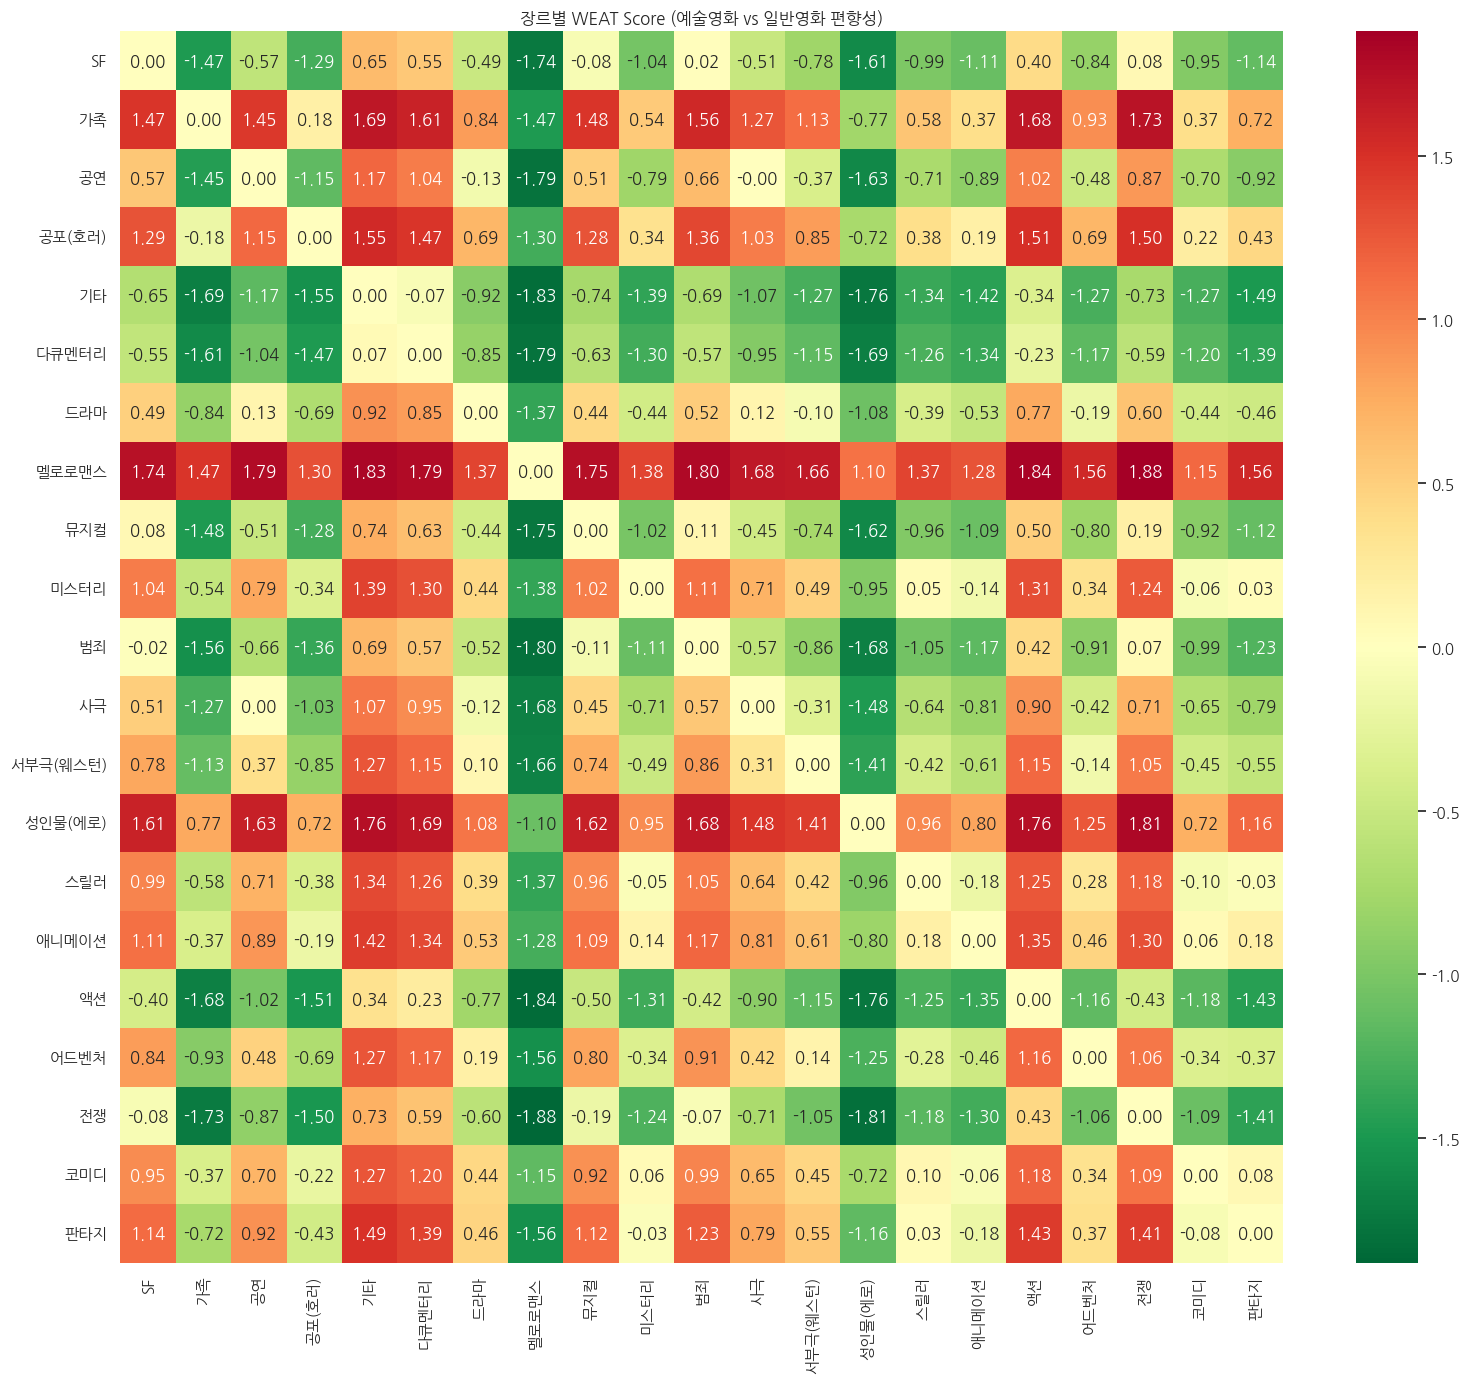

In [24]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')

import seaborn as sns
sns.set(font='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(16, 14))
ax = sns.heatmap(matrix, 
                 xticklabels=genre_name, 
                 yticklabels=genre_name, 
                 annot=True, 
                 fmt='.2f',
                 cmap='RdYlGn_r',
                 center=0)
plt.title('장르별 WEAT Score (예술영화 vs 일반영화 편향성)')
plt.tight_layout()
plt.show()

### 결과 해석
- 각 칸은 "행(X장르)이 열(Y장르)보다 예술영화에 얼마나 가까운가"를 나타낸다.
- 가족, 멜로로맨스, 성인물(에로) 등은 대부분의 장르와 비교했을 때 예술영화 쪽으로 편향되어 있다.
- 기타, 다큐멘터리, 액션, 전쟁 등은 일반영화 쪽으로 편향되어 있다.
- 이는 일반적으로 멜로/로맨스 장르가 예술영화로 분류되는 경향이 있고, 
  액션/전쟁 장르가 상업(일반)영화로 인식되는 상식과 부합하는 결과이다.
- 이를 통해 학습 데이터(영화 시놉시스)에 내재된 편향이 임베딩 모델에 반영되었음을 확인할 수 있다.